## VGG16: Training the model
### Loading python modules

In [1]:
from keras.utils import image_dataset_from_directory
from keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from collections import Counter
import random
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
!pip install prettypyplot
import prettypyplot as pplt
import seaborn as sns

import cv2
import os
import shutil
from PIL import Image

2025-08-20 11:33:13.265122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755689593.444133      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755689593.498573      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 1.8 MB/s eta 0:00:00


### Loading datasets

In [2]:
train_ds=image_dataset_from_directory('/kaggle/input/dataset-spain-germany/train_oversampling_resize',seed=42,batch_size=16)
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('/kaggle/input/dataset-spain-germany/val_resize',seed=42,batch_size=16,label_mode='int')
test_ds=image_dataset_from_directory('/kaggle/input/dataset-spain-germany/test_resize',seed=42,batch_size=16,label_mode='int')

Found 66136 files belonging to 8 classes.


I0000 00:00:1755689643.965204      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4805 files belonging to 8 classes.
Found 4814 files belonging to 8 classes.


### Preprocessing the datasets

In [3]:
train_ds_pre=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds_pre=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds_pre=test_ds.map(lambda x,y:(preprocess_input(x),y))

### Defining the model

In [4]:
inputs=Input(shape=(None,None,3))
x=Resizing(224,224)(inputs)
#x=Rescaling(1/255)(x)
base_model=VGG16(weights='imagenet',include_top=False,input_tensor=x)
#base_model.trainable=False
for layer in base_model.layers[-4:]:
    layer.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

  1: input_layer                              — Trainable: False
  2: resizing                                 — Trainable: False
  3: block1_conv1                             — Trainable: False
  4: block1_conv2                             — Trainable: False
  5: block1_pool                              — Trainable: False
  6: block2_conv1                             — Trainable: False
  7: block2_conv2                             — Trainable: False
  8: block2_pool                              — Trainable: False
  9: block3_conv1                             — Trainable: False
 10: block3_conv2                             — Trainable: False
 11: block3_conv3                             — Trainable: False
 12: block3_pool                              — Trainable: False
 13: block4_conv1                             — Trainable: False
 14: block4_conv2                             — Trainable: False
 15: block4_conv3                             — Trainable: False
 16: block4_pool         

### Define early stopping and reduce learning rate functions

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=5,             # wait 5 epochs before stopping
    mode='min',min_delta=0.01,
    restore_best_weights=True  # keep the best weights
)
reduceLR=ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=3,
                           min_delta=0.01,cooldown=4)

### Setting the optimizer and its learning rate and compiling the model

In [7]:
optim=Adam(1e-5)
model.compile(loss='sparse_categorical_crossentropy',optimizer=optim,metrics=['accuracy'])

### Training the model

In [8]:
history_model=model.fit(train_ds_pre,validation_data=val_ds_pre,epochs=100,callbacks=[early_stopping,reduceLR])

Epoch 1/100


I0000 00:00:1755689662.248535     106 service.cc:148] XLA service 0x7e18e01126e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755689662.249207     106 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755689662.797484     106 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/4134 ━━━━━━━━━━━━━━━━━━━━ 7:08 104ms/step - accuracy: 0.0938 - loss: 7.6658  

I0000 00:00:1755689669.531905     106 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4134/4134 ━━━━━━━━━━━━━━━━━━━━ 280s 65ms/step - accuracy: 0.7511 - loss: 0.7350 - val_accuracy: 0.9613 - val_loss: 0.1276 - learning_rate: 1.0000e-05
Epoch 2/100
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 255s 62ms/step - accuracy: 0.9710 - loss: 0.0931 - val_accuracy: 0.9675 - val_loss: 0.1055 - learning_rate: 1.0000e-05
Epoch 3/100
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 255s 62ms/step - accuracy: 0.9834 - loss: 0.0515 - val_accuracy: 0.9746 - val_loss: 0.0996 - learning_rate: 1.0000e-05
Epoch 4/100
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 257s 62ms/step - accuracy: 0.9901 - loss: 0.0318 - val_accuracy: 0.9757 - val_loss: 0.1004 - learning_rate: 1.0000e-05
Epoch 5/100
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 257s 62ms/step - accuracy: 0.9927 - loss: 0.0217 - val_accuracy: 0.9669 - val_loss: 0.1454 - learning_rate: 1.0000e-05
Epoch 6/100
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 259s 63ms/step - accuracy: 0.9972 - loss: 0.0090 - val_accuracy: 0.9794 - val_loss: 0.1050 - learning_rate: 1.0000e-06
Epoch 7/100
4134/4134 ━━━━━━━━━━━━━━━━━━

### Plot the loss and the accuracy curves

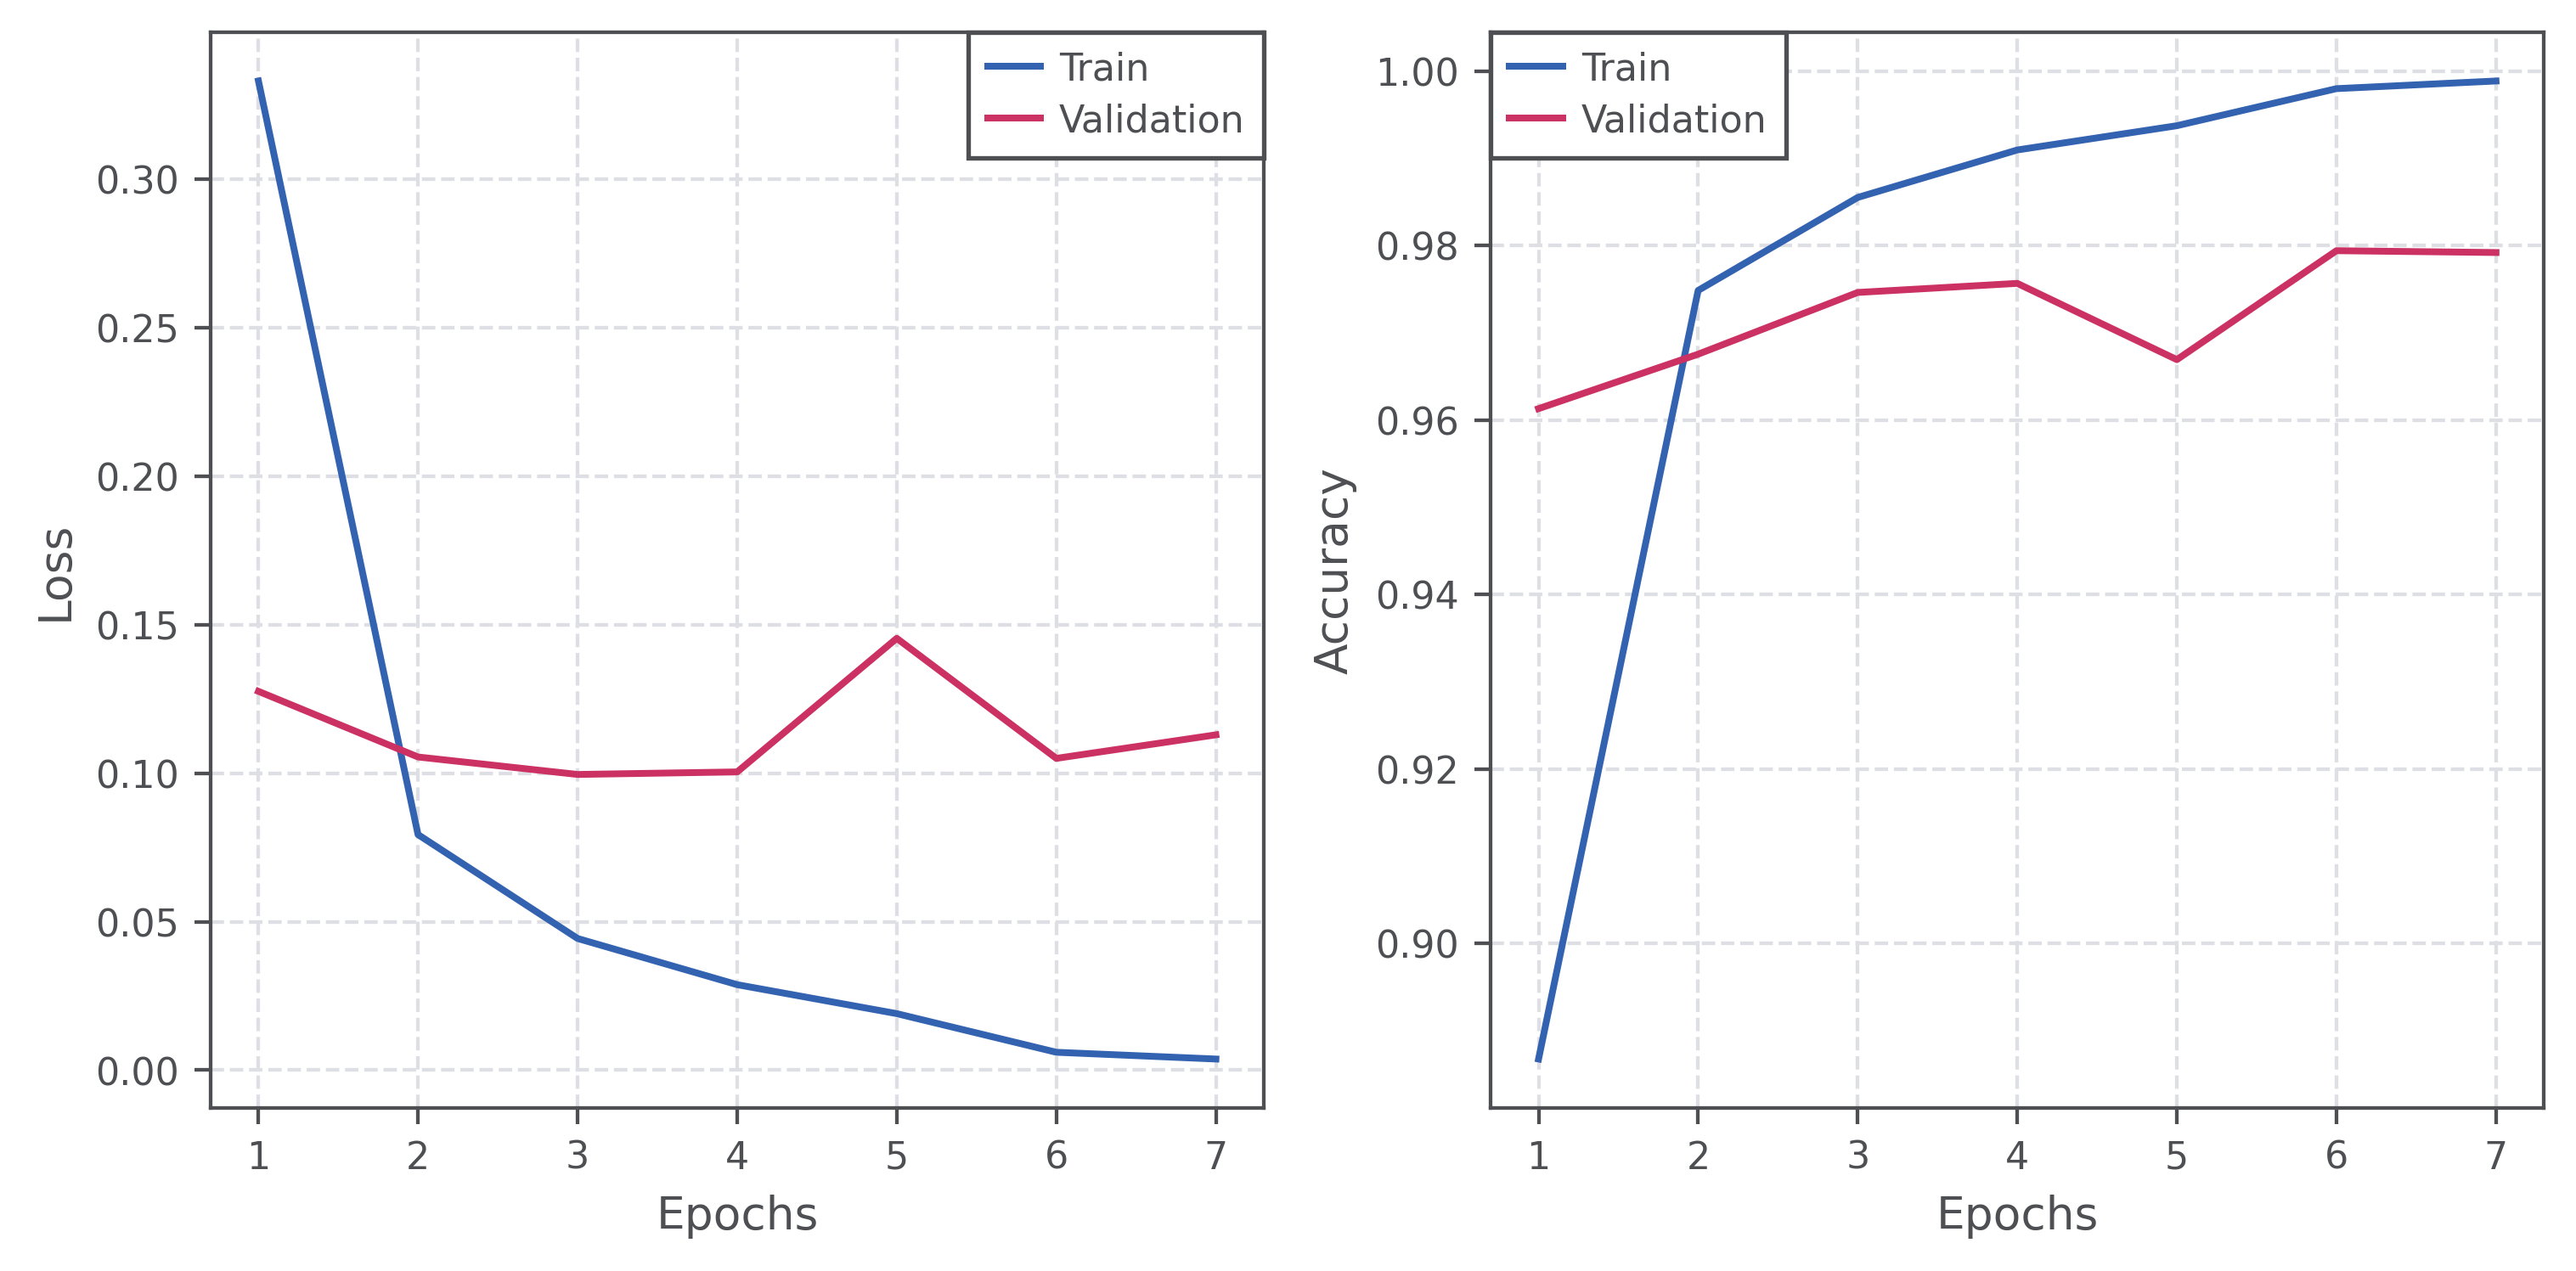

In [14]:
pplt.use_style()
loss=history_model.history['loss']
val_loss=history_model.history['val_loss']
accuracy=history_model.history['accuracy']
val_accuracy=history_model.history['val_accuracy']
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_val_vgg16.pdf');

### Evaluate the model on the test dataset

In [10]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds_pre)
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.96      0.94      0.95       195
  eosinophil       0.99      0.97      0.98       532
erythroblast       0.95      0.95      0.95       245
          ig       0.95      0.88      0.92       459
  lymphocyte       0.98      0.95      0.96       774
    monocyte       0.92      0.93      0.93       483
  neutrophil       0.95      0.99      0.97      1773
    platelet       0.99      0.99      0.99       353

    accuracy                           0.96      4814
   macro avg       0.96      0.95      0.96      4814
weighted avg       0.96      0.96      0.96      4814



### Compute and plot the confusion matrix

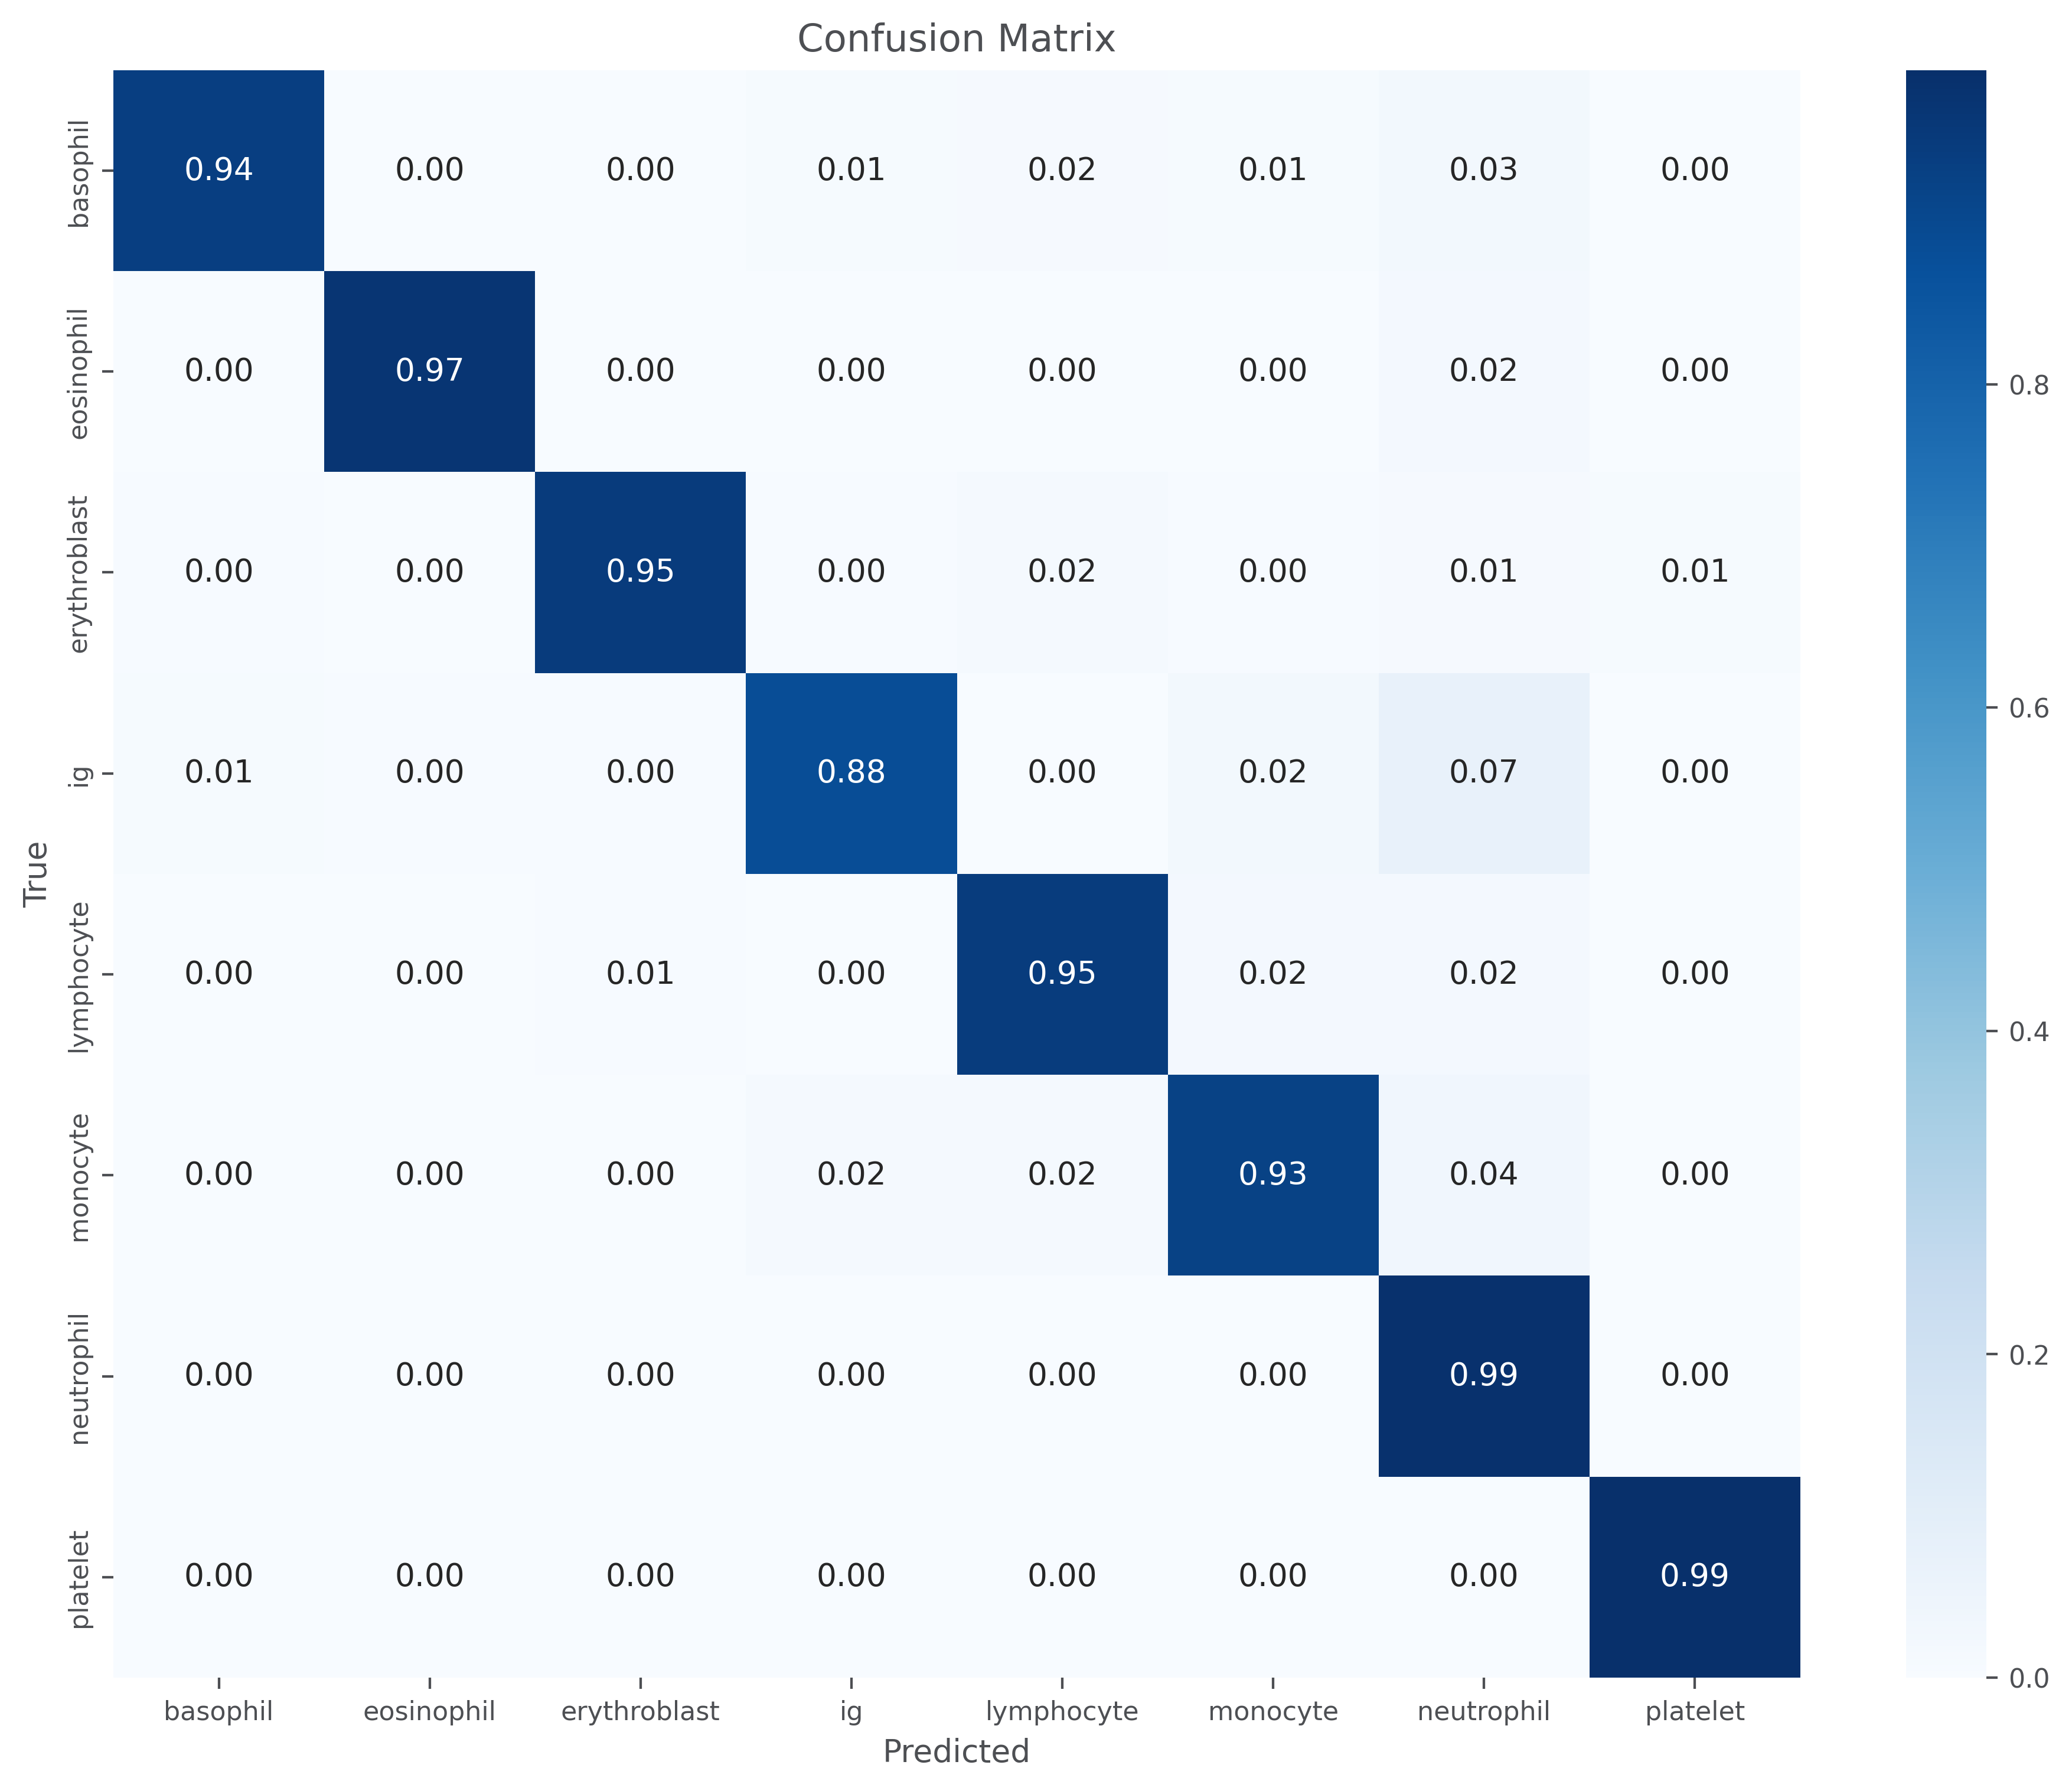

In [15]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm_vgg16.pdf')
plt.show()

### Save the model and the training history

In [12]:
import pickle

with open('training_history_vgg.pkl', 'wb') as f:
    pickle.dump(history_model.history, f)

model.save('vgg16_model.h5')
model.save('vgg16_model.keras')